# EL-GHALI MOHAMED

# Régression Polynomiale


In [10]:
# Importation des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Définition des Fonctions Mathématiques

Nous conservons ici l'approche pédagogique avec des boucles `for` imbriquées. Cela permet de voir exactement comment chaque puissance de $X$ est calculée,

In [11]:
# Création de la matrice avec les caractéristiques polynomiales (x^0, x^1, ..., x^degree)
def polynomial_features(X, degree):
    n = len(X)
    X_poly = np.zeros((n, degree + 1))

    # On utilise des boucles pour bien décomposer la création des puissances successives
    for i in range(n):
        for d in range(degree + 1):
            X_poly[i][d] = X[i] ** d

    return X_poly

# Initialisation des poids (les coefficients du polynôme) à zéro
def initialize_beta(degree):
    return np.zeros(degree + 1)

# Fonction de prédiction
def predict(X_poly, beta):
    n = len(X_poly)
    y_pred = np.zeros(n)

    # Somme pondérée : on multiplie chaque caractéristique (x^d) par son poids (beta)
    for i in range(n):
        for j in range(len(beta)):
            y_pred[i] += X_poly[i][j] * beta[j]

    return y_pred

# Fonction de coût (Erreur Quadratique Moyenne - MSE)
def compute_cost(y_pred, Y):
    n = len(Y)
    cost = 0

    # Calcul explicite de la somme des erreurs au carré
    for i in range(n):
        cost += (y_pred[i] - Y[i]) ** 2

    return cost / (2*n)

# L'algorithme d'entraînement principal : la descente de gradient
def polynomial_regression(X_poly, Y, beta, lr, iterations):
    n = len(Y)
    losses = [] # Ajout d'une liste pour tracer la courbe d'apprentissage

    for it in range(iterations):
        y_pred = predict(X_poly, beta)

        # Enregistrement de l'erreur
        current_cost = compute_cost(y_pred, Y)
        losses.append(current_cost)

        gradients = np.zeros(len(beta))

        # Calcul du gradient pour chaque paramètre
        for j in range(len(beta)):
            grad = 0
            for i in range(n):
                grad += (y_pred[i] - Y[i]) * X_poly[i][j]

            gradients[j] = (1 / n) * grad

        # Mise à jour des poids
        for j in range(len(beta)):
            beta[j] -= lr * gradients[j]

        # Affichage pour vérifier que l'erreur ne part pas vers l'infini (divergence)
        if it % 5000 == 0:
            print(f"Itération {it} | Cost: {current_cost:.2f}")

    return beta, losses

## 2. Création du Dataset Expérimental

 nous générons 12 mois de données (les index de 1 à 12 simulent le temps) avec un prix qui suit une légère courbe (tendance quadratique) pour justifier l'usage d'un polynôme.

In [12]:
# données simulées : Évolution du prix sur 12 mois avec une tendance non-linéaire (courbe)
data_dict = {
    "Month_Index": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "Price": [1500, 1480, 1475, 1490, 1530, 1590, 1660, 1750, 1860, 1990, 2150, 2300]
}

# Conversion en DataFrame Pandas pour faciliter la manipulation
data = pd.DataFrame(data_dict)
data.head()

,Month_Index,Price
0,1,1500
1,2,1480
2,3,1475
3,4,1490
4,5,1530


## 3. Entraînement et Affichage
nos valeurs de base vont de $1$ à $12$. Au degré $2$, la valeur maximale dans la matrice polynomiale sera $12^2 = 144$. Multiplié par des prix de plus de $2000$, les gradients sont lourds.


Début de l'entraînement...
Itération 0 | Cost: 1535642.71
Itération 5000 | Cost: 80358.00
Itération 10000 | Cost: 67026.80
Itération 15000 | Cost: 62256.97
Itération 20000 | Cost: 58006.89
Itération 25000 | Cost: 54051.58
Itération 30000 | Cost: 50366.14
Itération 35000 | Cost: 46932.02
Itération 40000 | Cost: 43732.09
Itération 45000 | Cost: 40750.39

Coefficients trouvés (beta) : [551.41291281 273.39822562 -12.31125924]


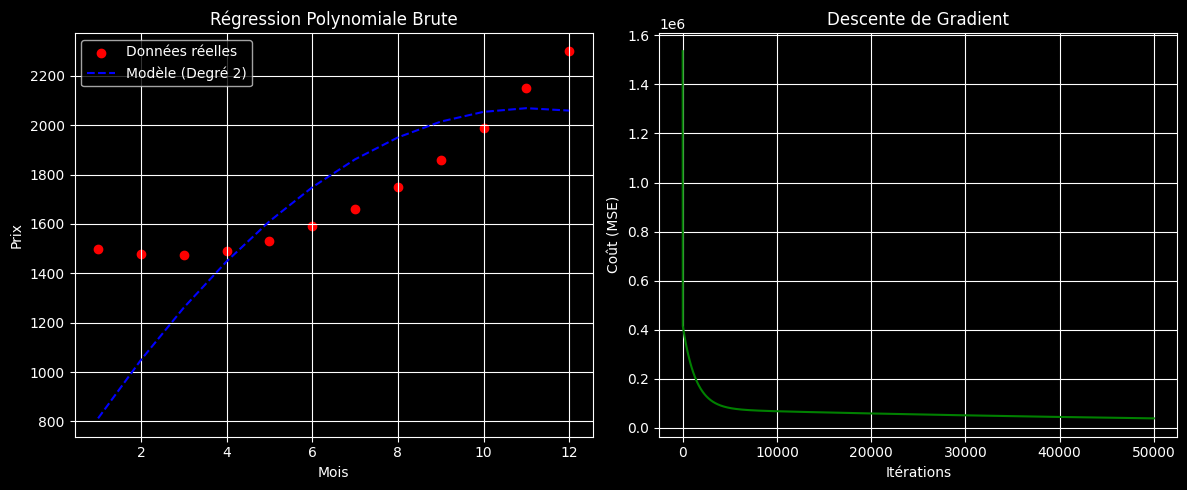

In [13]:
# Extraction des variables brutes
X = data["Month_Index"].values
Y = data["Price"].values

# Paramètres contraints par l'absence de normalisation
degree = 2
X_poly = polynomial_features(X, degree)

# Lancement de l'entraînement
beta_init = initialize_beta(degree)
lr = 1e-4
iterations = 50000

print("Début de l'entraînement...")
beta_final, losses = polynomial_regression(X_poly, Y, beta_init, lr, iterations)

print("\nCoefficients trouvés (beta) :", beta_final)

# --- VISUALISATION ---
plt.figure(figsize=(12, 5))

# Graphique 1 : La courbe de prédiction
plt.subplot(1, 2, 1)
Y_pred = predict(X_poly, beta_final)
plt.scatter(X, Y, color='red', label="Données réelles")
plt.plot(X, Y_pred, color='blue', linestyle="--", label=f"Modèle (Degré {degree})")
plt.xlabel("Mois")
plt.ylabel("Prix")
plt.title("Régression Polynomiale Brute")
plt.legend()
plt.grid(True)

# Graphique 2 : La courbe d'apprentissage (Loss)
plt.subplot(1, 2, 2)
plt.plot(losses, color='green')
plt.xlabel("Itérations")
plt.ylabel("Coût (MSE)")
plt.title("Descente de Gradient")
plt.grid(True)

plt.tight_layout()
plt.show()